In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

# dm1_flat = xp.rot90(xp.rot90( utils.load_fits('data/dm1_flat_command_96.fits') ))
# M = fraunhofer.MODEL()
# dm1_flat += 1e-9*xp.random.randn(M.Nact,M.Nact) * M.dm_mask

/home/kianmilani/miniconda3/envs/gpu311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


/home/kianmilani/Projects/adefc-vortex/aefc_vortex
[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


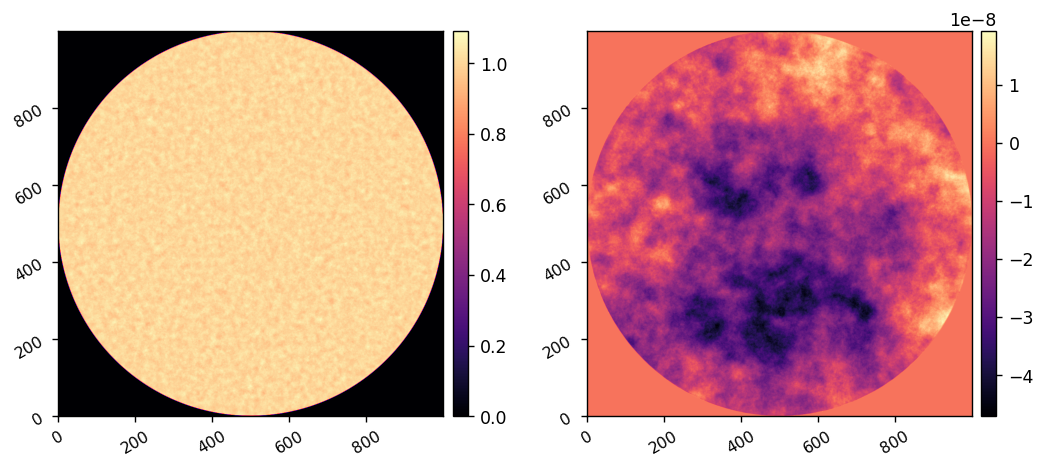

In [3]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

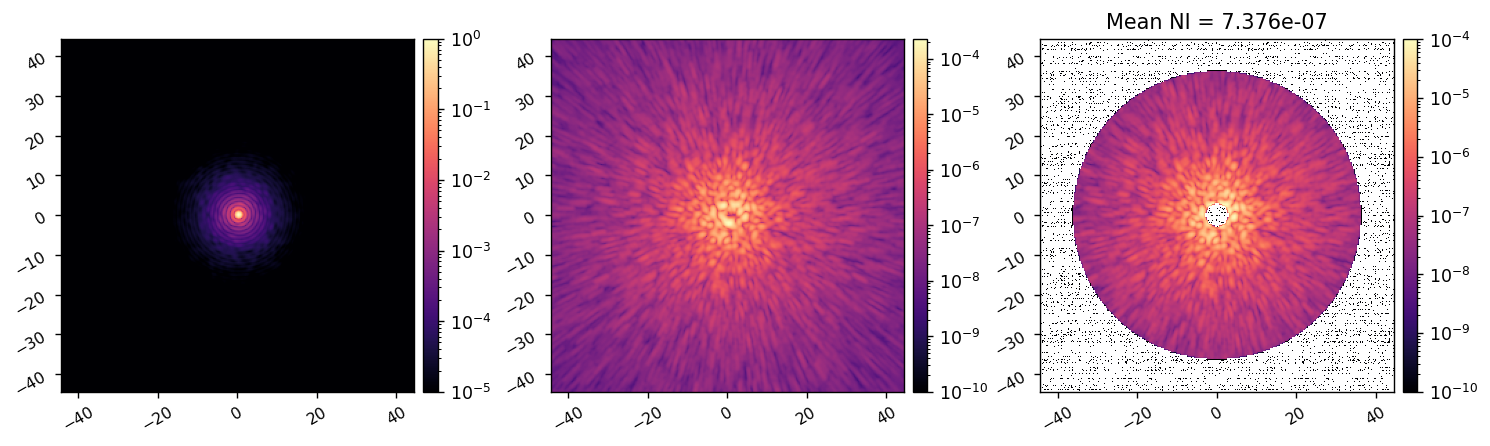

In [5]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=None, rotation=rot)
# control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)


In [8]:
mem_usage_from_fresnel_model = 3.798

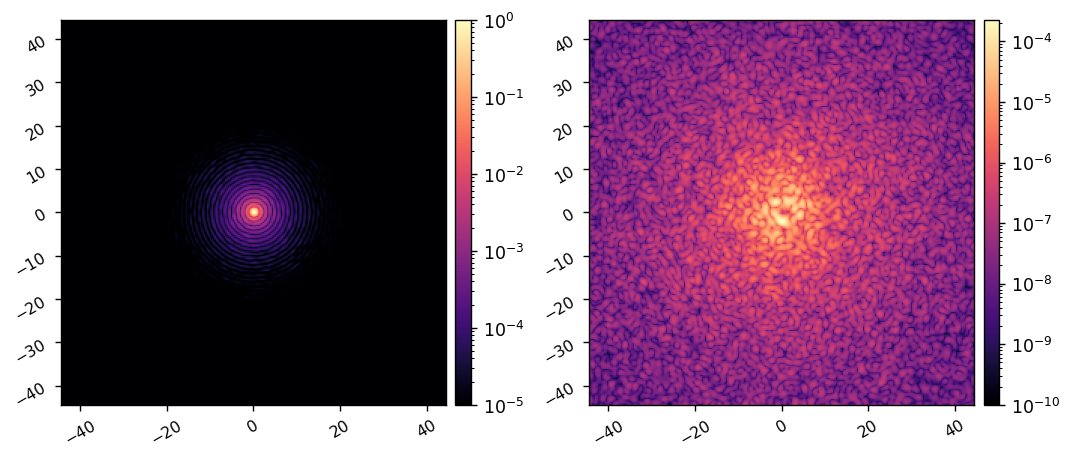

In [6]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

In [7]:
mem_usage_with_forward_model = 6.614

In [9]:
I.reset_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

In [11]:
mem_usage_while_doing_aefc = 8.534

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.07448D+06


 This problem is unconstrained.



At iterate    1    f=  9.96124D-01    |proj g|=  1.42912D+06

At iterate    2    f=  9.89806D-01    |proj g|=  5.30579D+05

At iterate    3    f=  9.87464D-01    |proj g|=  6.11562D+05

At iterate    4    f=  9.82298D-01    |proj g|=  6.58579D+05

At iterate    5    f=  9.80279D-01    |proj g|=  8.63360D+05

At iterate    6    f=  9.77800D-01    |proj g|=  4.32030D+05

At iterate    7    f=  9.76486D-01    |proj g|=  3.19559D+05

At iterate    8    f=  9.76079D-01    |proj g|=  4.10326D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
14736      8     14      1     0     0   4.103D+05   9.761D-01
  F =  0.976079200248

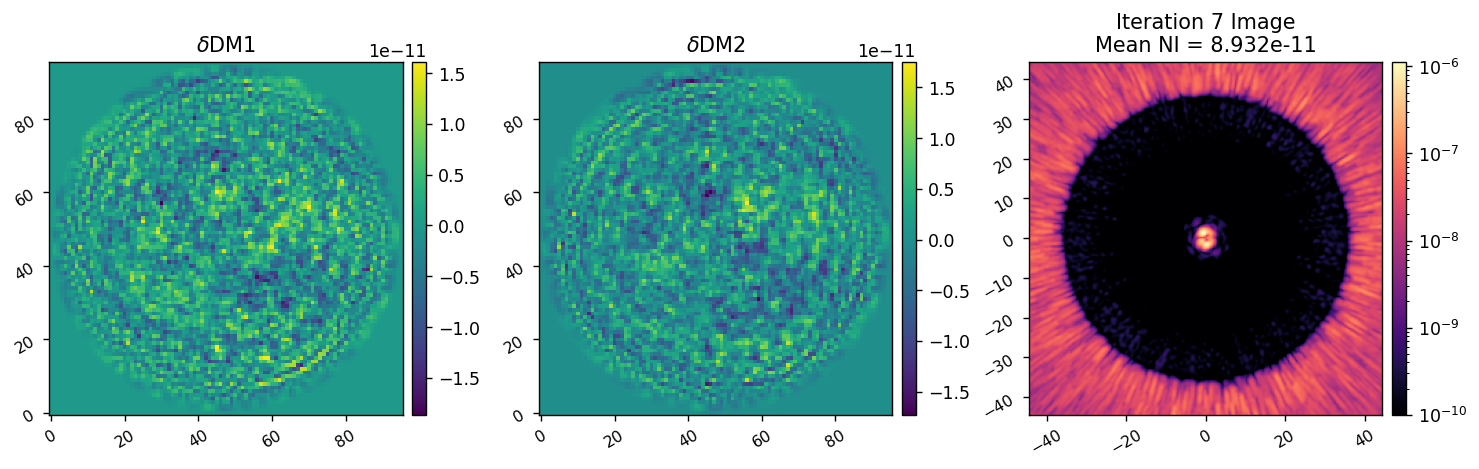

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  4.51004D+05


 This problem is unconstrained.



At iterate    1    f=  9.99786D-01    |proj g|=  3.72325D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
14736      1      4      1     0     0   3.723D+05   9.998D-01
  F =  0.99978590713211535     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


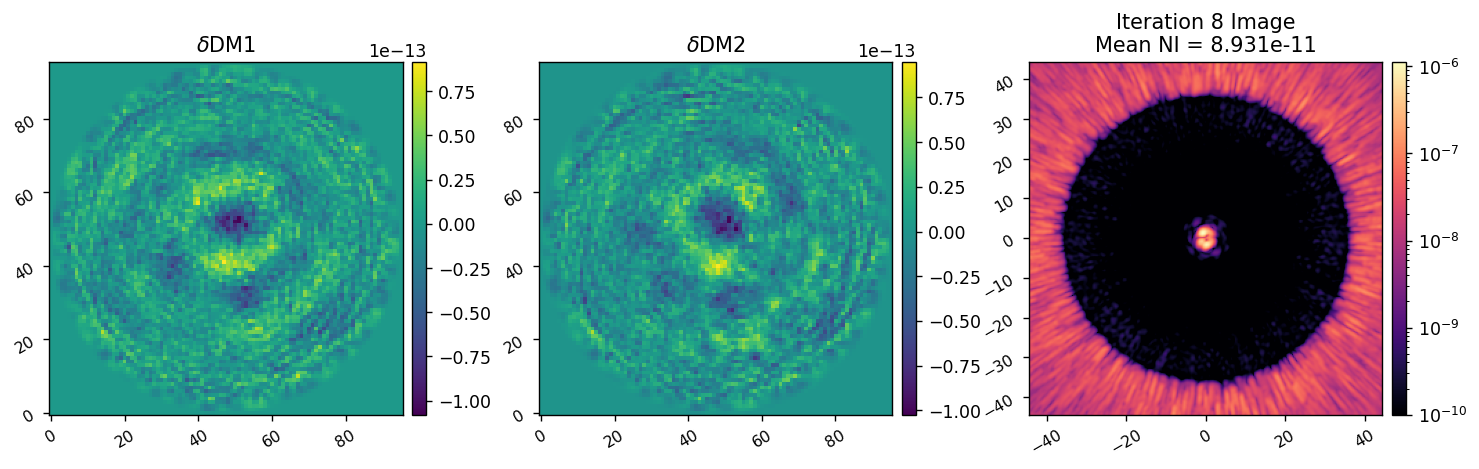

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  3.74514D+05


 This problem is unconstrained.



At iterate    1    f=  9.99655D-01    |proj g|=  2.60068D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
14736      1      4      1     0     0   2.601D+05   9.997D-01
  F =  0.99965516114028430     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


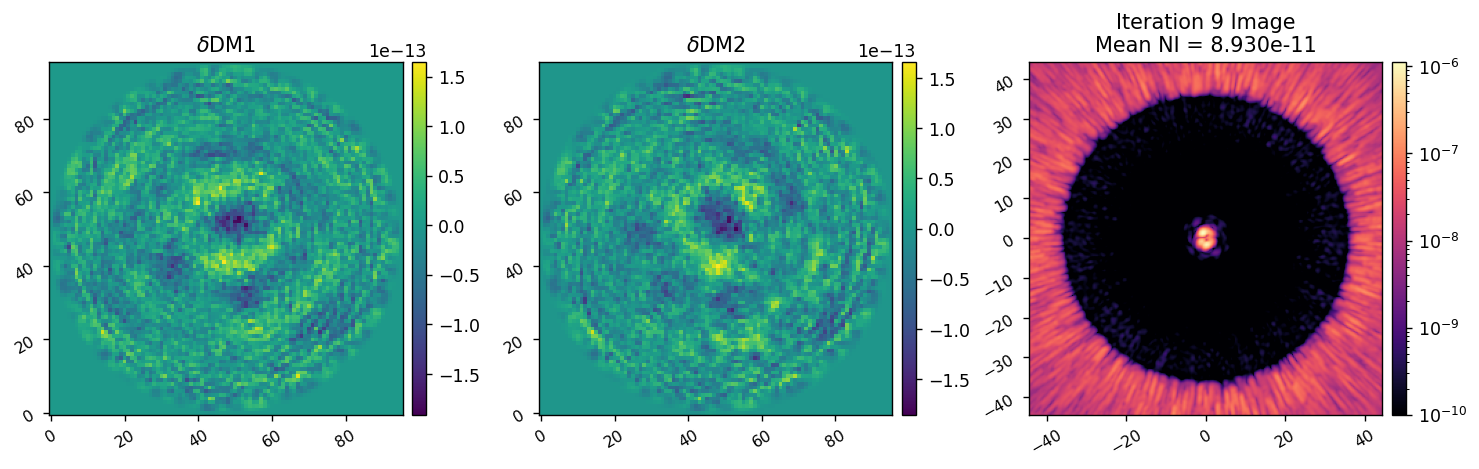

In [ ]:
reload(fraunhofer)
reload(aefc)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
# bfgs_tol = 1e-4
# bfgs_tol = 1e-5
# bfgs_tol = 1e-10

bfgs_opts = {
    'disp':True,
    'maxls':10, 
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run_bb(
    I, 
    M, 
    fraunhofer.val_and_grad_bb, 
    control_mask, 
    data,
    # Nitr=3, reg_cond=1e-1,
    # Nitr=3, reg_cond=1e-2,
    # Nitr=3, reg_cond=1e-3,
    # Nitr=3, reg_cond=1e-4,
    # Nitr=3, reg_cond=1e-5,
    # Nitr=3, reg_cond=1e-6,
    # Nitr=3, reg_cond=1e-7,
    # Nitr=3, reg_cond=1e-8,
    # Nitr=3, reg_cond=1e-12,
    # weights=np.array([20,1,20]), 
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)



In [14]:
print(mem_usage_from_fresnel_model, mem_usage_with_forward_model, mem_usage_while_doing_aefc)

3.798 6.614 8.534


In [20]:
model_mem_usage = mem_usage_with_forward_model - mem_usage_from_fresnel_model
print(model_mem_usage*1.074)

aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_with_forward_model
print(aefc_mem_usage*1.074)

total_mem_usage = mem_usage_while_doing_aefc - mem_usage_from_fresnel_model
print(total_mem_usage*1.074)

3.024384
2.062080000000001
5.086464000000001


In [10]:
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
now = datetime.now().strftime('%Y%m%d%H%M%S')
utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_3-10_run_{now}.pkl', data)

Saved data to:  /npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_3-10_run_20250425111922.pkl


In [2]:
import aefc_vortex.imshows as imshows

imshows.plot_howfsc_data(
    data, 
    vmin=5e-11, 
    vmax=1e-6,
    im1vmin=1e-9, 
    im1vmax=1e-4,
    im2vmin=1e-12, 
    im2vmax=1e-6,    
    xticks=np.linspace(0,9,10),
)

NameError: name 'data' is not defined

In [1]:
small_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.psf_pixelscale_lamDc, 
    irad=iwa, 
    orad=5, 
    edge=None, 
    rotation=0,
)

mean_nis = xp.mean(xp.array(data['images'])[:, control_mask], axis=1)
small_nis = xp.mean(xp.array(data['images'])[:, small_mask], axis=1)
print(small_nis)

utils.imshow([small_mask])
import matplotlib.pyplot as plt

plt.semilogy(ensure_np_array(mean_nis), label='Total Mean NI')
plt.semilogy(ensure_np_array(small_nis), label='3-5 Mean NI')
plt.grid()
plt.legend(fontsize=12)

NameError: name 'utils' is not defined

[1.75761068e-05 7.90588961e-08 5.38908977e-09 1.11975970e-09
 4.12918487e-10 1.91918224e-10 1.28756548e-10 1.09620179e-10
 1.01201792e-10 9.30274997e-11]


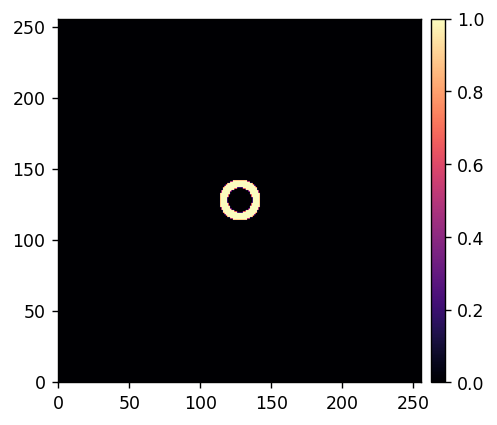

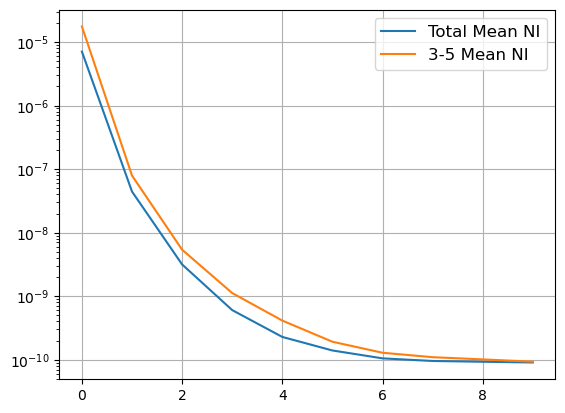

In [ ]:
small_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.psf_pixelscale_lamDc, 
    irad=iwa, 
    orad=5, 
    edge=None, 
    rotation=0,
)


mean_nis = xp.mean(xp.array(data['images'])[:, control_mask], axis=1)
small_nis = xp.mean(xp.array(data['images'])[:, small_mask], axis=1)
print(small_nis)

utils.imshow([small_mask])
import matplotlib.pyplot as plt

plt.semilogy(ensure_np_array(mean_nis), label='Total Mean NI')
plt.semilogy(ensure_np_array(small_nis), label='3-5 Mean NI')
plt.grid()
plt.legend(fontsize=12)